# Creating Plots for Data Viz 

In [130]:
#packages
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt

In [131]:
#loading data
df = pd.read_parquet('/Users/pdeguz01/Documents/git/IDS705_TeamPandas/00-Data/Data Viz Data/MergedDataset.parquet')

In [132]:
#df details
col_list = df.columns.tolist()

In [133]:
print(col_list)

['INSPECTION_DATE', 'STORE_NAME', 'STREET_ADDRESS', 'CITY', 'ZIP5', 'SERVICE_DESCRIPTION', 'SCORE', 'GRADE', 'STREET_ADDRESS_LINE2', 'INSPDATE_YEAR', 'Latitude', 'Longitude', 'Accuracy Score', 'Accuracy Type', 'Number', 'Street', 'Unit Type', 'Unit Number', 'City', 'State', 'County', 'Zip', 'Country', 'Source', 'geometry', 'buffer', 'STATEFP', 'COUNTYFP', 'TRACTCE', 'PRIMARY_CENSUSTRACT', 'GEOIDFQ', 'NAME', 'NAMELSAD', 'MTFCC', 'FUNCSTAT', 'ALAND', 'AWATER', 'INTPTLAT', 'INTPTLON', 'AVG_INCOME_NEARBY_TRACTS', 'AVG_HH_SIZE_NEARBY_TRACTS', 'AVG_RENT_NEARBY_TRACTS', 'AVG_POP_NEARBY_TRACTS', 'ST_ABBR', 'LOCATION', 'AREA_SQMI', 'E_TOTPOP', 'E_HU', 'E_HH', 'E_POV150', 'E_UNEMP', 'E_HBURD', 'E_NOHSDP', 'E_UNINSUR', 'E_AGE65', 'E_AGE17', 'E_DISABL', 'E_SNGPNT', 'E_LIMENG', 'E_MINRTY', 'E_MUNIT', 'E_MOBILE', 'E_CROWD', 'E_NOVEH', 'E_GROUPQ', 'EP_POV150', 'EP_UNEMP', 'EP_HBURD', 'EP_NOHSDP', 'EP_UNINSUR', 'EP_AGE65', 'EP_AGE17', 'EP_DISABL', 'EP_SNGPNT', 'EP_LIMENG', 'EP_MINRTY', 'EP_MUNIT', 'EP

In [134]:
#cleaning vars
df["SCORE"] = pd.to_numeric(df["SCORE"], errors="coerce")
df["RPL_THEMES"] = pd.to_numeric(df["RPL_THEMES"], errors="coerce")
df["RPL_THEMES"] = df["RPL_THEMES"].replace(-999, pd.NA)


# Plot 1

A density bar plot for the count of how many not passing restaurants there are in social vulnerable areas
So like a histogram (but data is filtered to restaurants that don’t pass, and the y axis is the number of restaurants and x axis is the Social Vulnerability Index scores)


In [135]:
#filter df
plotting_cols = ["INSPECTION_DATE", "STORE_NAME", "SCORE", "RPL_THEMES"]
df_filtered = df[plotting_cols]


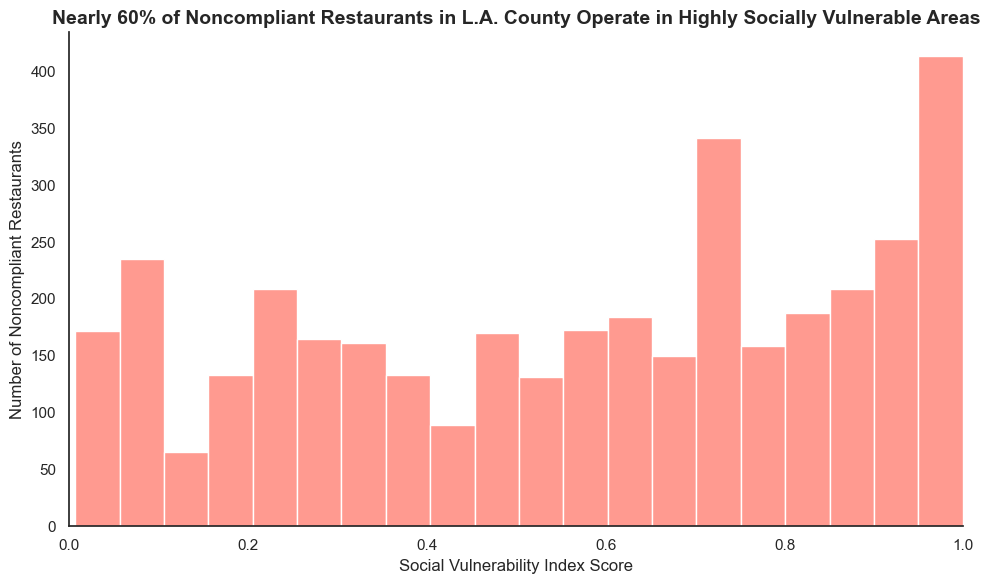

In [157]:
# Convert RPL_THEMES to numeric and filter to failing
df_fail = df[df["SCORE"] < 90].dropna(subset=["RPL_THEMES"])
df_fail = df_fail[plotting_cols]
plt.figure(figsize=(10,6))
sns.set_style("white")

sns.histplot(
    data=df_fail,
    x="RPL_THEMES",
    bins=20,
    color="#FF6F61",       
    #edgecolor="black",      
    alpha=0.7               
)
plt.xlabel("Social Vulnerability Index Score", fontsize=12)
plt.ylabel("Number of Noncompliant Restaurants", fontsize=12)
plt.title("Nearly 60% of Noncompliant Restaurants in L.A. County Operate in Highly Socially Vulnerable Areas", fontsize=14, weight="bold")
sns.despine()
plt.xlim(0,1)               
plt.tight_layout()
plt.show()

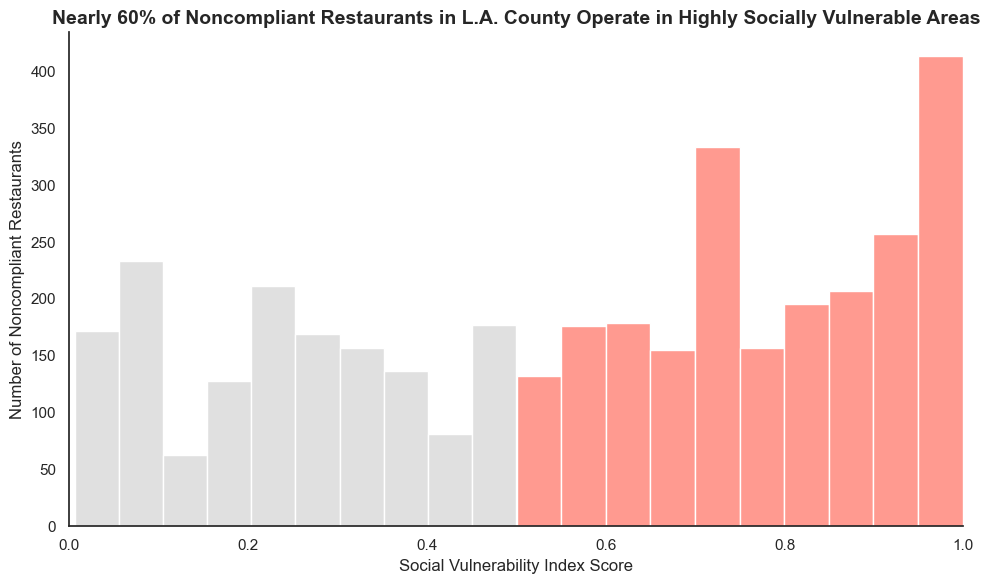

In [156]:
plt.figure(figsize=(10,6))
sns.set_style("white")

# Subsets
df_low = df_fail[df_fail["RPL_THEMES"] < 0.5]
df_high = df_fail[df_fail["RPL_THEMES"] >= 0.5]

# Plot < 0.5 as gray
sns.histplot(
    data=df_low,
    x="RPL_THEMES",
    bins=10,
    color="lightgray",
    #edgecolor="black",
    alpha=0.7
)

# Plot >= 0.5 as your original red color
sns.histplot(
    data=df_high,
    x="RPL_THEMES",
    bins=10,
    color="#FF6F61",
    #edgecolor="black",
    alpha=0.7
)

plt.xlabel("Social Vulnerability Index Score", fontsize=12)
plt.ylabel("Number of Noncompliant Restaurants", fontsize=12)
plt.title("Nearly 60% of Noncompliant Restaurants in L.A. County Operate in Highly Socially Vulnerable Areas",
          fontsize=14, weight="bold")
sns.despine()
plt.xlim(0, 1)
plt.tight_layout()
plt.show()

#Nearly 60% of restuarants in LA county are in the top half of highly socially vulnerable Census tracts.

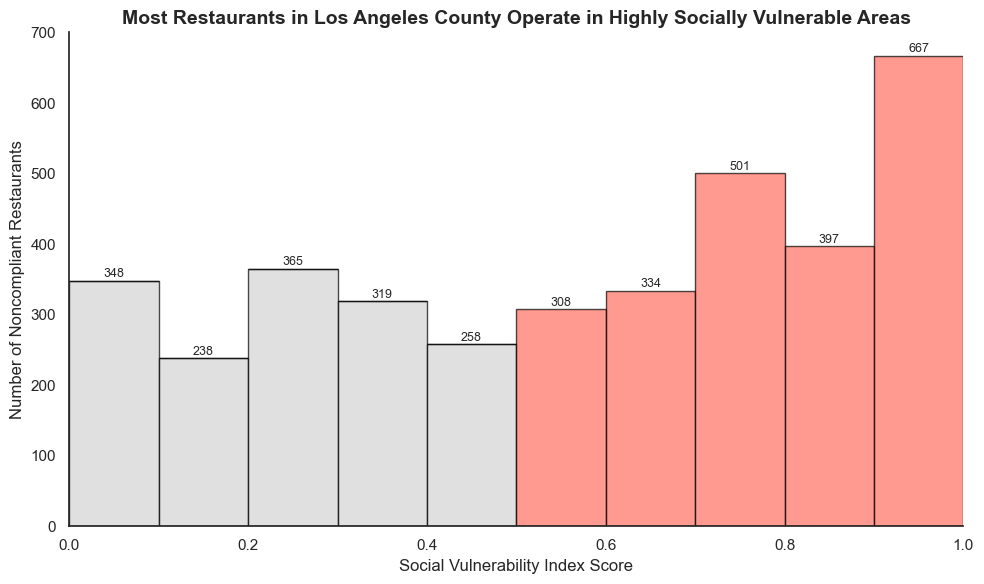

In [146]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10,6))
sns.set_style("white")

# Subsets
df_low = df_fail[df_fail["RPL_THEMES"] < 0.5]
df_high = df_fail[df_fail["RPL_THEMES"] >= 0.5]

bins = 10
bin_edges = np.linspace(0, 1, bins + 1)

# Compute histogram counts
low_counts, _ = np.histogram(df_low["RPL_THEMES"], bins=bin_edges)
high_counts, _ = np.histogram(df_high["RPL_THEMES"], bins=bin_edges)

# Bar widths and positions
width = bin_edges[1] - bin_edges[0]
bin_centers = bin_edges[:-1] + width/2

# Plot low group (gray)
plt.bar(bin_centers, low_counts, 
        width=width, color="lightgray", edgecolor="black", alpha=0.7, label="< 0.5")

# Plot high group (stacked on top, matching seaborn stacking)
plt.bar(bin_centers, high_counts, 
        width=width, bottom=low_counts, color="#FF6F61", edgecolor="black", alpha=0.7, label="≥ 0.5")

# Add text labels for total counts
total_counts = low_counts + high_counts
for x, y in zip(bin_centers, total_counts):
    if y > 0:
        plt.text(x, y + 0.5, str(y), ha="center", va="bottom", fontsize=9)

plt.xlabel("Social Vulnerability Index Score", fontsize=12)
plt.ylabel("Number of Noncompliant Restaurants", fontsize=12)
plt.title("Most Restaurants in Los Angeles County Operate in Highly Socially Vulnerable Areas",
          fontsize=14, weight="bold")
sns.despine()
plt.xlim(0, 1)
plt.tight_layout()
plt.show()


In [ ]:
#3733 total restuarants in failing dataset


# Plot 2

Maybe a plot with like 5-10 top Census tracts with the most poorly performing restaurants (group by Census tracts, rank by # of restaurants that did not pass inspection)
Incorporate # of violations


In [138]:
#prep data

In [139]:
#plotting